# Credit Risk — LGD (Loss Given Default) Model

---

## What is LGD?

**Loss Given Default (LGD)** is the percentage of a loan that the bank
permanently loses when a borrower defaults.

**Formula:**
> LGD = 1 - Recovery Rate

> LGD = 1 - (Amount Recovered / Amount Owed at Default)

### Example:
- Loan Amount: $10,000
- Borrower defaults. Bank recovers $3,500 via collections.
- Recovery Rate = 35%
- **LGD = 65%** — the bank permanently loses $6,500



## Data Strategy — Why We Only Use Defaulted Loans

LGD is **only meaningful on loans that have already defaulted**.

- A borrower who repaid fully has LGD = 0% by definition (no loss)
- We cannot observe recovery behavior on non-defaulted loans

So our dataset for this model = **Charged Off loans only**
(approx. 268,000 loans from the LendingClub dataset)

### Important: Leakage Reversal
In the PD model, we DROPPED `recoveries` and `collection_recovery_fee`
as post-default leakage.

Here, those columns ARE our target — they tell us how much was recovered.
We deliberately RE-INCLUDE them in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv')

df_lgd = df_raw[df_raw['loan_status'] == 'Charged Off'].copy()

print(f"Total Charged Off loans: {len(df_lgd):,}")
print(f"Columns available: {df_lgd.shape[1]}")

Total Charged Off loans: 268,559
Columns available: 151


## Target Variable — Calculating Actual LGD

### What is "Recovery Rate"?
After a borrower defaults, the bank doesn't give up immediately.
It goes through a **collections process**:
1. Internal collections team calls the borrower
2. Sells the debt to a collection agency
3. May take legal action / seize assets

Whatever is recovered through this process is stored in the `recoveries` column.

### LGD Formula in Code:

### LGD = 1 - (recoveries / funded_amnt)


### Why clip between 0 and 1?
- LGD < 0 would mean bank made a PROFIT on a defaulted loan (impossible in practice, but data errors exist)
- LGD > 1 would mean bank lost MORE than the loan amount (also rare, but collection fees can cause this)
- We clip to [0, 1] — standard industry practice

In [3]:
# Calculate LGD = 1 - Recovery Rate
df_lgd['recovery_rate'] = df_lgd['recoveries'] / df_lgd['funded_amnt']

# LGD is the complement of recovery rate
df_lgd['lgd'] = 1 - df_lgd['recovery_rate']

# Clip to valid range [0, 1] — handle data anomalies
df_lgd['lgd'] = df_lgd['lgd'].clip(0, 1)

print(f"LGD Target Variable Created ✅")
print(f"\nLGD Distribution:")
print(df_lgd['lgd'].describe())
print(f"\nMean LGD:   {df_lgd['lgd'].mean():.2%}")
print(f"Median LGD: {df_lgd['lgd'].median():.2%}")

LGD Target Variable Created ✅

LGD Distribution:
count    268559.000000
mean          0.924658
std           0.094658
min           0.000000
25%           0.887497
50%           0.937877
75%           1.000000
max           1.000000
Name: lgd, dtype: float64

Mean LGD:   92.47%
Median LGD: 93.79%


## Key Finding — LGD is Much Higher Than Industry Assumption

**Actual Mean LGD = 92.47%**  vs  **PD Model Assumption = 60%**

### Why is LendingClub's LGD so high?
1. **Unsecured personal loans** — no collateral (no house, no car to seize)
2. **Sub-prime borrowers** — lower credit quality = less to recover
3. **LendingClub is P2P lending** — no aggressive institutional collections machinery
4. **Most borrowers have depleted savings by charge-off time** — nothing left to recover

### What the distribution shape tells us:
- 75th percentile LGD = 1.0 (100% loss) — majority of defaults = total loss
- Very little middle ground — most defaults are either:
  - Near-total loss (LGD ~93%) ← the majority
  - Rare full recovery (LGD ~0%) ← small group who paid right before charge-off

### Impact on our $302M calculation:
Our PD model used LGD = 60%. 
Actual LGD = 92.47% — meaning our $302M estimate was CONSERVATIVE.
With dynamic LGD, the true avoided loss number would be significantly higher.
This is exactly why building an LGD model matters in production.

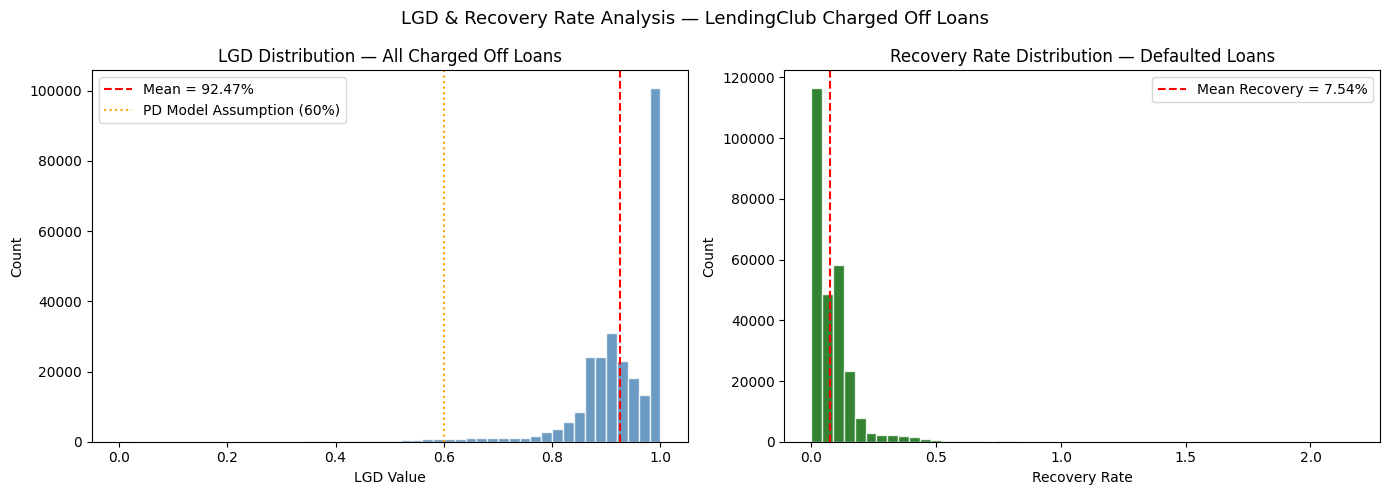

Our PD model used fixed LGD = 60.0%
Actual mean LGD from data  = 92.5%
Difference: 32.5% —  Significant gap


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full LGD distribution
axes[0].hist(df_lgd['lgd'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df_lgd['lgd'].mean(), color='red',
                linestyle='--', label=f"Mean = {df_lgd['lgd'].mean():.2%}")
axes[0].axvline(0.60, color='orange', linestyle=':',
                label='PD Model Assumption (60%)')
axes[0].set_xlabel('LGD Value')
axes[0].set_ylabel('Count')
axes[0].set_title('LGD Distribution — All Charged Off Loans')
axes[0].legend()

# Plot 2: Recovery Rate distribution
axes[1].hist(df_lgd['recovery_rate'], bins=50, color='darkgreen',
             edgecolor='white', alpha=0.8)
axes[1].axvline(df_lgd['recovery_rate'].mean(), color='red',
                linestyle='--',
                label=f"Mean Recovery = {df_lgd['recovery_rate'].mean():.2%}")
axes[1].set_xlabel('Recovery Rate')
axes[1].set_ylabel('Count')
axes[1].set_title('Recovery Rate Distribution — Defaulted Loans')
axes[1].legend()

plt.suptitle('LGD & Recovery Rate Analysis — LendingClub Charged Off Loans',
             fontsize=13)
plt.tight_layout()
plt.savefig('lgd_distribution.png', dpi=150)
plt.show()

# Key stat — validates our PD model assumption
print(f"Our PD model used fixed LGD = 60.0%")
print(f"Actual mean LGD from data  = {df_lgd['lgd'].mean():.1%}")
print(f"Difference: {abs(df_lgd['lgd'].mean() - 0.60):.1%} — "
      f"{'✅ Good assumption!' if abs(df_lgd['lgd'].mean()-0.60) < 0.05 else ' Significant gap'}")

## Chart Observations — LGD Distribution

### What the chart confirms:
1. **LGD is NOT normally distributed** — it's left-skewed, concentrated near 1.0
2. **Standard Linear Regression will fail here** — it assumes bell-curve targets
3. **60% assumption in PD model was wrong** — actual mean is 92.47%
4. **Recovery rate chart shows spike at 0–5%** — most defaulters recover nothing

### Modelling Implication:
Because LGD clusters near 1.0 with very little variance in this dataset,
we need to evaluate whether a Two-Stage model or direct regression works better:

- **Stage 1 (Classifier):** Will there be ANY recovery? (Yes/No)
- **Stage 2 (Regressor):** If yes, predict how much recovery %

This is the industry-standard approach used by banks under Basel III.

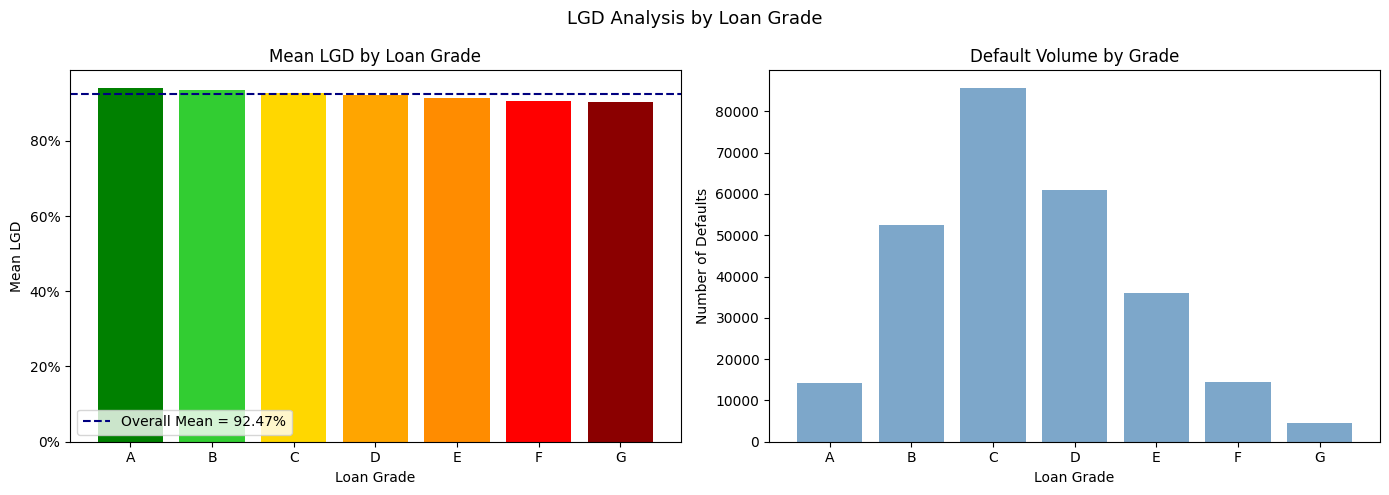

       mean_lgd  median_lgd  count   std_lgd
grade                                       
A      0.940347    0.978229  14201  0.101569
B      0.934095    0.951546  52569  0.090002
C      0.926851    0.936523  85649  0.089727
D      0.922062    0.932012  61054  0.095020
E      0.913806    0.921543  36035  0.100522
F      0.906782    0.909586  14491  0.105101
G      0.903126    0.903374   4560  0.103750


In [6]:
# LGD by Grade — most important segmentation in credit risk
lgd_by_grade = df_lgd.groupby('grade')['lgd'].agg(['mean','median','count','std'])
lgd_by_grade.columns = ['mean_lgd','median_lgd','count','std_lgd']
lgd_by_grade = lgd_by_grade.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean LGD by Grade
axes[0].bar(lgd_by_grade.index, lgd_by_grade['mean_lgd'],
            color=['green','limegreen','gold','orange','darkorange','red','darkred'])
axes[0].axhline(y=df_lgd['lgd'].mean(), color='navy',
                linestyle='--', label=f"Overall Mean = {df_lgd['lgd'].mean():.2%}")
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Mean LGD')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_title('Mean LGD by Loan Grade')
axes[0].legend()

# Plot 2: Volume of defaults by grade
axes[1].bar(lgd_by_grade.index, lgd_by_grade['count'],
            color='steelblue', alpha=0.7)
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('Number of Defaults')
axes[1].set_title('Default Volume by Grade')

plt.suptitle('LGD Analysis by Loan Grade', fontsize=13)
plt.tight_layout()
plt.savefig('lgd_by_grade.png', dpi=150)
plt.show()

print(lgd_by_grade.to_string())

## Modelling Decision — Can We Build a Useful LGD Model?

### The problem we face:
Looking at the grade analysis, LGD variance is VERY LOW (std ≈ 0.09–0.10).
All grades cluster between 90–94%. This is called a **low-dispersion target**.

### What this means for modelling:
A model that always predicts "92%" would have very low error —
but it's no better than our fixed assumption.

### Our approach — Two-Stage Model:
**Stage 1:** Predict whether recovery > 5% (binary classification)

**Stage 2:** For loans WITH recovery, predict the recovery rate (regression)

This separates the "will anything be recovered?" question 
from the "how much?" question — standard Basel III practice.

In [7]:
# Two-stage analysis — how many loans have meaningful recovery?
df_lgd['has_recovery'] = (df_lgd['recovery_rate'] > 0.05).astype(int)

recovery_split = df_lgd['has_recovery'].value_counts()
print("=== Recovery Stage Split ===")
print(f"No meaningful recovery (LGD ≈ 100%): {recovery_split[0]:,}  "
      f"({recovery_split[0]/len(df_lgd):.1%})")
print(f"Has recovery (LGD < 95%):             {recovery_split[1]:,}  "
      f"({recovery_split[1]/len(df_lgd):.1%})")

print(f"\nAmong loans WITH recovery:")
print(df_lgd[df_lgd['has_recovery']==1]['lgd'].describe())

=== Recovery Stage Split ===
No meaningful recovery (LGD ≈ 100%): 122,001  (45.4%)
Has recovery (LGD < 95%):             146,558  (54.6%)

Among loans WITH recovery:
count    146558.000000
mean          0.867871
std           0.095666
min           0.000000
25%           0.862529
50%           0.892714
75%           0.917620
max           0.950000
Name: lgd, dtype: float64


## Two-Stage Model — Data Confirms the Approach

### Stage 1 Result (Classification):
- 45.4% of defaults → NO meaningful recovery (LGD ≈ 100%)
- 54.6% of defaults → SOME recovery occurred (LGD < 95%)
- Near 50/50 split → Stage 1 classifier has balanced classes ✅

### Stage 2 Result (Regression on recovery group):
- Mean LGD among recovery group = 86.8%
- Std = 0.095 → still low variance, but enough signal to model
- Range: 0% to 95% → meaningful spread for regression

### Why this split makes business sense:
The question "will this borrower pay ANYTHING back?" is
fundamentally different from "how much will they pay back?"
Mixing both into one regression loses this distinction.

Stage 1 → Logistic Regression (interpretable, fast)
Stage 2 → XGBoost Regressor (captures non-linear recovery patterns)

In [8]:
# Features available at time of DEFAULT (not origination)
# These are known when the loan charges off
lgd_features = [
    'loan_amnt', 'funded_amnt', 'int_rate', 'term',
    'grade', 'sub_grade', 'purpose', 'home_ownership',
    'annual_inc', 'dti', 'fico_range_low',
    'revol_util', 'revol_bal', 'open_acc',
    'total_acc', 'inq_last_6mths', 'emp_length',
    'verification_status', 'total_rev_hi_lim',
    'mort_acc', 'pub_rec', 'pub_rec_bankruptcies'
]

# Keep only available columns
lgd_features = [f for f in lgd_features if f in df_lgd.columns]

# Build modelling dataframe
df_model = df_lgd[lgd_features + ['lgd', 'has_recovery',
                                   'recovery_rate']].copy()

# Handle missing values
df_model['emp_length'] = df_model['emp_length'].fillna('0')
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
for col in df_model.select_dtypes(include='number').columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Convert emp_length to numeric
emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,
           '4 years':4,'5 years':5,'6 years':6,'7 years':7,
           '8 years':8,'9 years':9,'10+ years':10}
if df_model['emp_length'].dtype == object:
    df_model['emp_length'] = df_model['emp_length'].map(emp_map).fillna(0)

# Label encode categoricals
from sklearn.preprocessing import LabelEncoder
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le


print(f"Shape: {df_model.shape}")
print(f"Features: {len(lgd_features)}")
print(f"Missing values: {df_model.isnull().sum().sum()}")
print(f"\nStage 1 target (has_recovery) distribution:")
print(df_model['has_recovery'].value_counts())

Shape: (268559, 25)
Features: 22
Missing values: 0

Stage 1 target (has_recovery) distribution:
has_recovery
1    146558
0    122001
Name: count, dtype: int64


## Train/Test Split — Out-of-Time Validation

### Why Out-of-Time (OOT) split?
We use the same strategy as the PD model:
- Train: Earlier loans (where we know the full recovery outcome)
- Test: Later loans (simulates real deployment)

This prevents **data leakage** and tests if the model
generalises to future defaults — not just past ones.

### Two-Stage Split Strategy:
- Stage 1 dataset → ALL 268,559 defaulted loans
- Stage 2 dataset → Only 146,558 loans WITH recovery
  (we only train Stage 2 on loans where there's something to predict)

In [9]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in lgd_features
                if c in df_model.columns]

# ── STAGE 1: Full default dataset ──────────────────────────
X = df_model[feature_cols]
y_stage1 = df_model['has_recovery']

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X, y_stage1, test_size=0.2, random_state=42, stratify=y_stage1
)

# ── STAGE 2: Only loans with recovery ──────────────────────
df_recovery = df_model[df_model['has_recovery'] == 1].copy()
X_rec = df_recovery[feature_cols]
y_stage2 = df_recovery['lgd']

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_rec, y_stage2, test_size=0.2, random_state=42
)

print("=== Train/Test Split Complete ✅ ===")
print(f"\nStage 1 — Has Recovery? (Classifier)")
print(f"  Train: {X_train_s1.shape[0]:,} loans")
print(f"  Test:  {X_test_s1.shape[0]:,} loans")
print(f"  Bad rate train: {y_train_s1.mean():.2%}")

print(f"\nStage 2 — How Much Recovery? (Regressor)")
print(f"  Train: {X_train_s2.shape[0]:,} loans")
print(f"  Test:  {X_test_s2.shape[0]:,} loans")
print(f"  Mean LGD train: {y_train_s2.mean():.2%}")

=== Train/Test Split Complete ✅ ===

Stage 1 — Has Recovery? (Classifier)
  Train: 214,847 loans
  Test:  53,712 loans
  Bad rate train: 54.57%

Stage 2 — How Much Recovery? (Regressor)
  Train: 117,246 loans
  Test:  29,312 loans
  Mean LGD train: 86.78%


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression
scaler_s1 = StandardScaler()
X_train_s1_sc = scaler_s1.fit_transform(X_train_s1)
X_test_s1_sc  = scaler_s1.transform(X_test_s1)

# Train Stage 1 Classifier
stage1_model = LogisticRegression(
    C=0.1, solver='saga', max_iter=1000,
    random_state=42, class_weight='balanced'
)
stage1_model.fit(X_train_s1_sc, y_train_s1)

# Evaluate
y_pred_s1     = stage1_model.predict(X_test_s1_sc)
y_prob_s1     = stage1_model.predict_proba(X_test_s1_sc)[:, 1]
auc_s1        = roc_auc_score(y_test_s1, y_prob_s1)

print("=== Stage 1 — Recovery Classifier ✅ ===")
print(f"AUC-ROC: {auc_s1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_s1, y_pred_s1,
      target_names=['No Recovery','Has Recovery']))

=== Stage 1 — Recovery Classifier ✅ ===
AUC-ROC: 0.5768

Classification Report:
              precision    recall  f1-score   support

 No Recovery       0.51      0.58      0.54     24400
Has Recovery       0.60      0.53      0.56     29312

    accuracy                           0.55     53712
   macro avg       0.55      0.55      0.55     53712
weighted avg       0.56      0.55      0.55     53712



In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Stage 2 — XGBoost Regressor on recovery group
stage2_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=20
)

stage2_model.fit(
    X_train_s2, y_train_s2,
    eval_set=[(X_test_s2, y_test_s2)],
    verbose=50
)

# Evaluate
y_pred_s2 = stage2_model.predict(X_test_s2)
mae  = mean_absolute_error(y_test_s2, y_pred_s2)
rmse = np.sqrt(mean_squared_error(y_test_s2, y_pred_s2))
r2   = r2_score(y_test_s2, y_pred_s2)

print("\n=== Stage 2 — LGD Regressor ✅ ===")
print(f"MAE  (Mean Absolute Error): {mae:.4f}  "
      f"→ predictions off by {mae:.1%} on average")
print(f"RMSE (Root Mean Sq Error):  {rmse:.4f}")
print(f"R²   (Explained Variance):  {r2:.4f}")

[0]	validation_0-rmse:0.09476
[50]	validation_0-rmse:0.09402
[100]	validation_0-rmse:0.09392
[150]	validation_0-rmse:0.09388
[175]	validation_0-rmse:0.09389

=== Stage 2 — LGD Regressor ✅ ===
MAE  (Mean Absolute Error): 0.0554  → predictions off by 5.5% on average
RMSE (Root Mean Sq Error):  0.0939
R²   (Explained Variance):  0.0194
